# Global EDA Examples: PPG and ABP

Scan every source record in all four UCI data parts and plot dataset-wide examples and summaries for PPG and ABP.

The scan uses complete, non-overlapping five-second windows (625 samples at 125 Hz) and drops each record's incomplete tail.

The notebook retains per-window summary metrics and source coordinates, not all waveform windows. It reads the full raw dataset once for the scan, then reloads only the records needed for waveform plots.

Required files: `data/raw/Part_1.mat` through `Part_4.mat`.

Dependencies: `numpy`, `h5py`, `matplotlib`, and `scipy`. Install them in the project environment if needed with `python -m pip install numpy h5py matplotlib scipy`.

In [ ]:
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np

FS = 125
WINDOW_SIZE = 5 * FS
PART_FILES = [f"Part_{number}.mat" for number in range(1, 5)]

ROOT = Path.cwd()
if not (ROOT / "data" / "raw").is_dir():
    ROOT = ROOT.parent
RAW_DIR = ROOT / "data" / "raw"
missing_files = [name for name in PART_FILES if not (RAW_DIR / name).is_file()]
if missing_files:
    raise FileNotFoundError(
        f"Missing raw data files in {RAW_DIR}: {', '.join(missing_files)}. "
        "See data/README.md for dataset setup."
    )

print(f"Scanning all raw parts under: {RAW_DIR}")
print(f"Window size: {WINDOW_SIZE} samples ({WINDOW_SIZE / FS:.0f} seconds)")

Scanning all raw parts under: /Users/katherinewu/Desktop/Microsoft-1D-educational-blood-pressure-estimation/data/raw
Window size: 625 samples (5 seconds)


## Scan all records

This cell may take a while (~2 min) because it reads all source records. It builds compact arrays of SBP, DBP, PPG range, and source coordinates in matching order. The resulting window index can then identify a source record without retaining the full PPG and ABP dataset in memory.

In [ ]:
from scipy.signal import find_peaks

sbp_chunks = []
dbp_chunks = []
ppg_range_chunks = []
ppg_std_chunks = []
zero_count_chunks = []
location_chunks = []
record_window_counts = []
record_part_numbers = []
beat_sbp_values = []
beat_dbp_values = []
beat_sbp_differences = []
beat_dbp_differences = []
beat_sample_locations = []
record_count_total = 0
window_count_total = 0

zero_case_counts = {"exactly_one_zero": 0, "at_least_32_zeros": 0, "exactly_flat": 0}
zero_case_locations = {
    "exactly_one_zero": None,
    "at_least_32_zeros": None,
    "exactly_flat": None,
}
longest_zero_run_case = None
longest_zero_run_length = 0

for part_number, filename in enumerate(PART_FILES, start=1):
    with h5py.File(RAW_DIR / filename, "r") as source:
        references = source[f"Part_{part_number}"]
        for record_index in range(references.shape[0]):
            record = source[references[record_index, 0]][()]
            if record.ndim != 2 or record.shape[1] != 3:
                raise ValueError(
                    f"Unexpected shape in {filename}, record {record_index}: {record.shape}"
                )

            window_count = record.shape[0] // WINDOW_SIZE
            record_window_counts.append(window_count)
            record_part_numbers.append(part_number)
            if window_count == 0:
                record_count_total += 1
                continue

            windows = record[:window_count * WINDOW_SIZE].reshape(
                window_count, WINDOW_SIZE, 3
            )
            ppg = windows[:, :, 0]
            abp = windows[:, :, 1]
            sbp = abp.max(axis=1)
            dbp = abp.min(axis=1)
            ppg_range = np.ptp(ppg, axis=1)
            zero_counts = np.sum(ppg == 0, axis=1)

            sbp_chunks.append(sbp)
            dbp_chunks.append(dbp)
            ppg_range_chunks.append(ppg_range)
            ppg_std_chunks.append(ppg.std(axis=1))
            zero_count_chunks.append(zero_counts)
            location_chunks.append(
                np.column_stack(
                    (
                        np.full(window_count, part_number, dtype=np.int32),
                        np.full(window_count, record_index, dtype=np.int32),
                        np.arange(window_count, dtype=np.int32),
                    )
                )
            )

            one_zero_indices = np.flatnonzero(zero_counts == 1)
            many_zero_indices = np.flatnonzero(zero_counts >= 32)
            flat_indices = np.flatnonzero(ppg_range == 0)
            zero_case_counts["exactly_one_zero"] += len(one_zero_indices)
            zero_case_counts["at_least_32_zeros"] += len(many_zero_indices)
            zero_case_counts["exactly_flat"] += len(flat_indices)

            if zero_case_locations["exactly_one_zero"] is None and len(one_zero_indices):
                zero_case_locations["exactly_one_zero"] = (
                    part_number, record_index, int(one_zero_indices[0])
                )
            if zero_case_locations["at_least_32_zeros"] is None and len(many_zero_indices):
                zero_case_locations["at_least_32_zeros"] = (
                    part_number, record_index, int(many_zero_indices[0])
                )
            if zero_case_locations["exactly_flat"] is None and len(flat_indices):
                zero_case_locations["exactly_flat"] = (
                    part_number, record_index, int(flat_indices[0])
                )

            for window_index in many_zero_indices:
                zero_mask = ppg[window_index] == 0
                transitions = np.diff(np.r_[False, zero_mask, False].astype(np.int8))
                run_lengths = np.flatnonzero(transitions == -1) - np.flatnonzero(transitions == 1)
                run_length = int(run_lengths.max()) if len(run_lengths) else 0
                if run_length > longest_zero_run_length:
                    longest_zero_run_length = run_length
                    longest_zero_run_case = (
                        part_number, record_index, int(window_index), int(zero_counts[window_index])
                    )

            # Exploratory beat labels: first and every 40th window from each record.
            for window_index in range(0, window_count, 40):
                abp_window = abp[window_index]
                peaks, _ = find_peaks(abp_window, distance=40, prominence=10)
                troughs, _ = find_peaks(-abp_window, distance=40, prominence=10)
                if len(peaks) < 2 or len(troughs) < 2:
                    continue
                beat_sbp = float(np.median(abp_window[peaks]))
                beat_dbp = float(np.median(abp_window[troughs]))
                beat_sbp_values.append(beat_sbp)
                beat_dbp_values.append(beat_dbp)
                beat_sbp_differences.append(float(sbp[window_index] - beat_sbp))
                beat_dbp_differences.append(float(dbp[window_index] - beat_dbp))
                beat_sample_locations.append(
                    (part_number, record_index, int(window_index))
                )

            record_count_total += 1
            window_count_total += window_count

global_sbp = np.concatenate(sbp_chunks)
global_dbp = np.concatenate(dbp_chunks)
global_ppg_range = np.concatenate(ppg_range_chunks)
global_ppg_std = np.concatenate(ppg_std_chunks)
global_zero_counts = np.concatenate(zero_count_chunks)
window_locations = np.concatenate(location_chunks)
record_window_counts = np.asarray(record_window_counts, dtype=int)
record_part_numbers = np.asarray(record_part_numbers, dtype=int)
if not len(global_sbp):
    raise ValueError("No complete windows were found in the raw dataset.")

global_sbp_median = float(np.median(global_sbp))
print(f"Records scanned: {record_count_total:,}")
print(f"Complete windows scanned: {window_count_total:,}")
print(f"Global median window-max SBP: {global_sbp_median:.2f} mmHg")
print(f"Global SBP range: {global_sbp.min():.1f} to {global_sbp.max():.1f} mmHg")
print(f"Global DBP range: {global_dbp.min():.1f} to {global_dbp.max():.1f} mmHg")
print("\nPPG audit-case counts:")
print(f"  Exactly one zero: {zero_case_counts['exactly_one_zero']:,}")
print(f"  At least 32 zero samples: {zero_case_counts['at_least_32_zeros']:,}")
print(f"  Exactly flat windows: {zero_case_counts['exactly_flat']:,}")
if longest_zero_run_case is not None:
    print(
        f"Longest consecutive zero run among windows with at least 32 zeros: "
        f"{longest_zero_run_length} samples; location={longest_zero_run_case}"
    )

Records scanned: 12,000
Complete windows scanned: 528,828
Global median window-max SBP: 131.10 mmHg
Global SBP range: 63.4 to 200.0 mmHg
Global DBP range: 50.0 to 184.5 mmHg

PPG audit-case counts:
  Exactly one zero: 1,419
  At least 32 zero samples: 53
  Exactly flat windows: 0
Longest consecutive zero run among windows with at least 32 zeros: 21 samples; location=(1, 2016, 58, 36)


## Select and reload the four windows

The global median example is the window whose SBP is closest to the median of all window-max SBP values. The remaining examples are the global maximum SBP, global minimum DBP, and global minimum PPG range. Only their source records are reloaded for plotting.

In [ ]:
selected_ids = {
    "SBP nearest global median": int(
        np.argmin(np.abs(global_sbp - global_sbp_median))
    ),
    "Highest global SBP": int(np.argmax(global_sbp)),
    "Lowest global DBP": int(np.argmin(global_dbp)),
    "Smallest global PPG range": int(np.argmin(global_ppg_range)),
}

example_windows = {}
record_cache = {}
for title, global_id in selected_ids.items():
    part_number, record_index, window_index = map(
        int, window_locations[global_id]
    )
    filename = PART_FILES[part_number - 1]
    record_key = (part_number, record_index)

    if record_key not in record_cache:
        with h5py.File(RAW_DIR / filename, "r") as source:
            reference = source[f"Part_{part_number}"][record_index, 0]
            record_cache[record_key] = source[reference][()]

    start = window_index * WINDOW_SIZE
    window = record_cache[record_key][start:start + WINDOW_SIZE]
    if window.shape != (WINDOW_SIZE, 3):
        raise ValueError(
            f"Could not reload complete window {window_index} from "
            f"{filename}, record {record_index}."
        )

    example_windows[title] = {
        "part": filename,
        "record_index": record_index,
        "window_index": window_index,
        "ppg": window[:, 0].copy(),
        "abp": window[:, 1].copy(),
        "sbp": float(global_sbp[global_id]),
        "dbp": float(global_dbp[global_id]),
        "ppg_range": float(global_ppg_range[global_id]),
    }

for title, example in example_windows.items():
    print(
        f"{title}: SBP={example['sbp']:.1f}, DBP={example['dbp']:.1f} mmHg; "
        f"PPG range={example['ppg_range']:.4g}; "
        f"{example['part']} record {example['record_index']}, "
        f"window {example['window_index']}"
    )

SBP nearest global median: SBP=131.1, DBP=63.4 mmHg; PPG range=2.166; Part_1.mat record 1, window 15
Highest global SBP: SBP=200.0, DBP=72.9 mmHg; PPG range=1.649; Part_3.mat record 1103, window 4
Lowest global DBP: SBP=91.6, DBP=50.0 mmHg; PPG range=2.049; Part_1.mat record 2055, window 74
Smallest global PPG range: SBP=152.7, DBP=88.8 mmHg; PPG range=0.09775; Part_4.mat record 2608, window 2


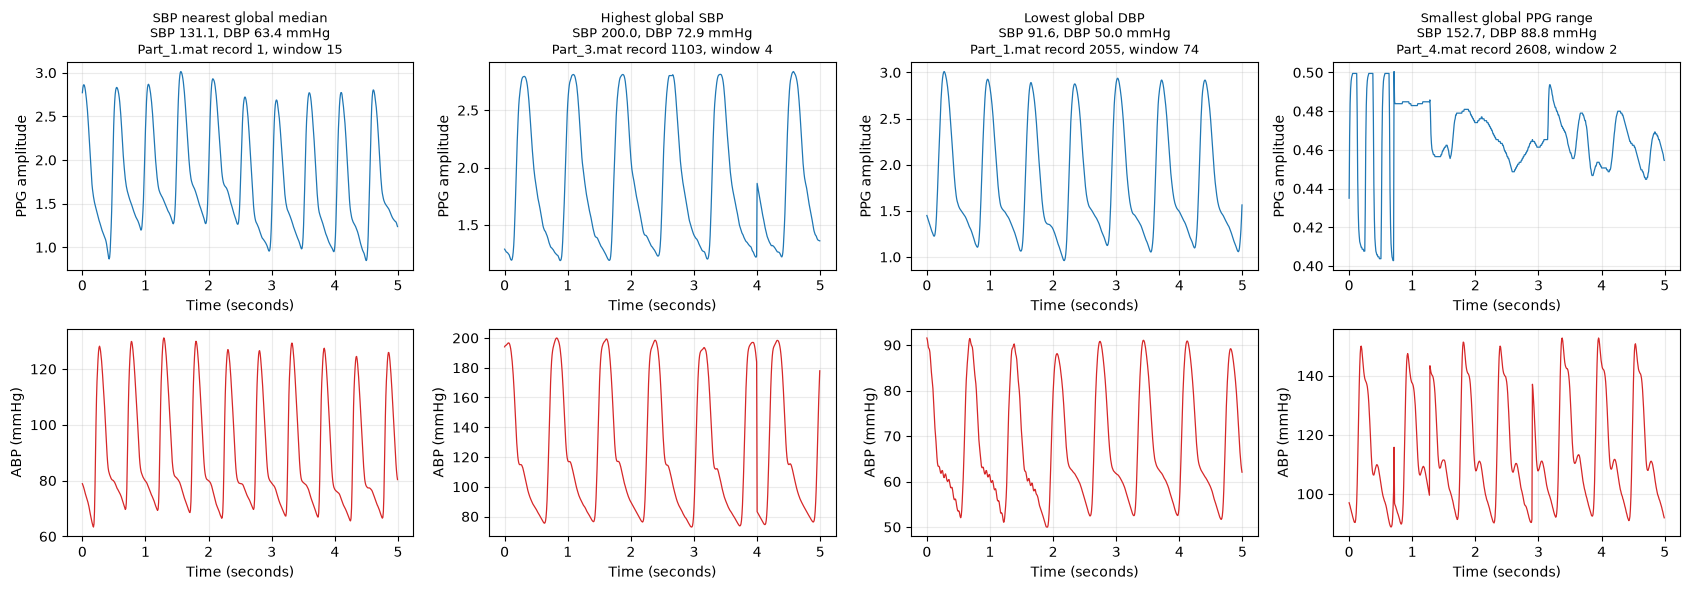

In [ ]:
example_titles = list(selected_ids)
time_seconds = np.arange(WINDOW_SIZE) / FS
fig, axes = plt.subplots(2, len(example_titles), figsize=(17, 6), squeeze=False)

for column, title in enumerate(example_titles):
    example = example_windows[title]
    source_id = (
        f"{example['part']} record {example['record_index']}, "
        f"window {example['window_index']}"
    )
    axes[0, column].plot(time_seconds, example["ppg"], linewidth=0.9)
    axes[0, column].set_title(
        f"{title}\nSBP {example['sbp']:.1f}, DBP {example['dbp']:.1f} mmHg\n{source_id}",
        fontsize=9,
    )
    axes[0, column].set_ylabel("PPG amplitude")
    axes[0, column].set_xlabel("Time (seconds)")
    axes[0, column].grid(alpha=0.25)

    axes[1, column].plot(time_seconds, example["abp"], color="tab:red", linewidth=0.9)
    axes[1, column].set_ylabel("ABP (mmHg)")
    axes[1, column].set_xlabel("Time (seconds)")
    axes[1, column].grid(alpha=0.25)

fig.tight_layout()
plt.show()

## Takeaways from these four examples

- The window nearest the global median SBP has regular-looking repeated pulses in both signals. Its SBP is 131.1 mmHg.

- The highest-SBP window reaches 200.0 mmHg, but the plot shows repeated high ABP peaks rather than one isolated spike. That makes it worth checking for a possible ceiling or saturation effect; the plot alone can’t tell whether it is an artifact.

- The lowest-DBP window reaches 50.0 mmHg, with troughs repeatedly near that level. That could reflect the signal or a lower-bound effect, and deserves review rather than automatic rejection.

- The smallest-PPG-range example is the most visibly suspicious: its PPG changes sharply at the beginning, then stays in a very narrow range, while ABP continues to show clear pulses. Its PPG range is small but not zero, so it is nearly flat, not one of the audit’s exactly flat windows.

## Compare PPG zero and flat-window cases

The full scan finds the first window with exactly one PPG zero and the window with the longest consecutive zero run among windows containing at least 32 zero samples (the audit's threshold). The dataset has no exactly flat PPG windows (`PPG range == 0`), so the plot uses the smallest-range window as a clearly labeled fallback. Each PPG trace is paired with ABP from the same samples. Zero counts and consecutive run length are distinct measurements.

No matching window found for: Exactly flat PPG


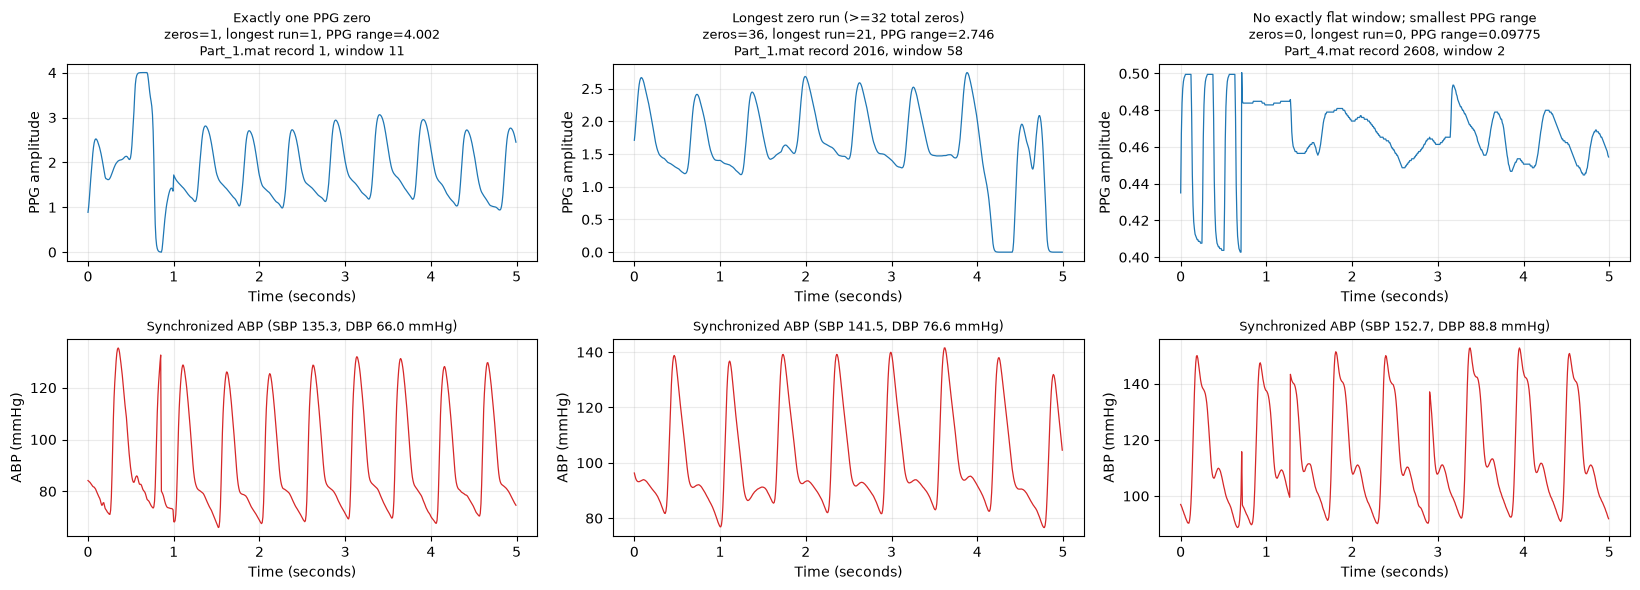

In [ ]:
qa_locations = {
    "Exactly one PPG zero": zero_case_locations["exactly_one_zero"],
    "Longest zero run (>=32 total zeros)": longest_zero_run_case[:3]
    if longest_zero_run_case is not None else None,
    "Exactly flat PPG": zero_case_locations["exactly_flat"],
}

if qa_locations["Exactly flat PPG"] is None:
    smallest_range_id = int(np.argmin(global_ppg_range))
    qa_locations["No exactly flat window; smallest PPG range"] = tuple(
        map(int, window_locations[smallest_range_id])
    )

qa_windows = {}
for title, location in qa_locations.items():
    if location is None:
        print(f"No matching window found for: {title}")
        continue

    part_number, record_index, window_index = map(int, location)
    filename = PART_FILES[part_number - 1]
    with h5py.File(RAW_DIR / filename, "r") as source:
        reference = source[f"Part_{part_number}"][record_index, 0]
        record = source[reference][()]

    start = window_index * WINDOW_SIZE
    window = record[start:start + WINDOW_SIZE]
    ppg_window = window[:, 0].copy()
    abp_window = window[:, 1].copy()
    zero_mask = ppg_window == 0
    transitions = np.diff(np.r_[False, zero_mask, False].astype(np.int8))
    run_lengths = np.flatnonzero(transitions == -1) - np.flatnonzero(transitions == 1)
    qa_windows[title] = {
        "part": filename,
        "record_index": record_index,
        "window_index": window_index,
        "ppg": ppg_window,
        "abp": abp_window,
        "zero_count": int(zero_mask.sum()),
        "longest_zero_run": int(run_lengths.max()) if len(run_lengths) else 0,
        "ppg_range": float(np.ptp(ppg_window)),
        "sbp": float(abp_window.max()),
        "dbp": float(abp_window.min()),
    }

qa_titles = list(qa_windows)
fig, axes = plt.subplots(2, len(qa_titles), figsize=(5.5 * len(qa_titles), 6), squeeze=False)

for column, title in enumerate(qa_titles):
    example = qa_windows[title]
    source_id = (
        f"{example['part']} record {example['record_index']}, "
        f"window {example['window_index']}"
    )
    title_detail = (
        f"zeros={example['zero_count']}, "
        f"longest run={example['longest_zero_run']}, "
        f"PPG range={example['ppg_range']:.4g}"
    )
    axes[0, column].plot(time_seconds, example["ppg"], linewidth=0.9)
    axes[0, column].set_title(f"{title}\n{title_detail}\n{source_id}", fontsize=9)
    axes[0, column].set_ylabel("PPG amplitude")
    axes[0, column].set_xlabel("Time (seconds)")
    axes[0, column].grid(alpha=0.25)

    axes[1, column].plot(time_seconds, example["abp"], color="tab:red", linewidth=0.9)
    axes[1, column].set_title(
        f"Synchronized ABP (SBP {example['sbp']:.1f}, DBP {example['dbp']:.1f} mmHg)",
        fontsize=9,
    )
    axes[1, column].set_ylabel("ABP (mmHg)")
    axes[1, column].set_xlabel("Time (seconds)")
    axes[1, column].grid(alpha=0.25)

fig.tight_layout()
plt.show()

# Significance

- One PPG zero (Part_1, record 1, window 11): the PPG briefly drops to zero and rebounds, while ABP continues pulsing. An isolated, abrupt zero is suspicious because it doesn’t resemble the surrounding pulse shape. It could be a measurement dropout or encoding issue, but one plot can’t establish the cause.

- Longer zero run (Part_1, record 2016, window 58): the window contains 36 zeros, including a consecutive run of 21 samples, about 0.17 seconds. ABP remains pulsatile during the PPG dropout. That makes a PPG-specific interruption more plausible than a pause in the underlying heartbeat, though it still needs verification.

- Smallest PPG range (Part_4, record 2608, window 2): the PPG range is only 0.09775, with abrupt early changes and relatively little variation afterward, while ABP shows clear pulses. This may indicate a weak, clipped, or otherwise poor PPG recording. It is not exactly flat; the full scan found no windows with PPG range exactly zero.

## Blood pressure label distributions and relationships

The following plots summarize the provisional whole-window ABP labels across all complete windows. Pulse pressure is derived as `SBP - DBP`. The dashed lines on its histogram use Tukey's 1.5×IQR fences as a statistical screening aid only; they are not clinical limits. Unusual values and pairs are candidates for waveform review, not automatic deletions.

Windows summarized: 528,828
SBP: min=63.4, 5th=99.0, Q1=115.9, median=131.1, Q3=148.0, 95th=174.4, max=200.0 mmHg
DBP: min=50.0, 5th=51.5, Q1=56.2, median=62.0, Q3=70.0, 95th=84.7, max=184.5 mmHg
Pulse pressure (SBP - DBP): min=5.1, 5th=36.2, Q1=55.0, median=67.5, Q3=81.4, 95th=103.3, max=148.5 mmHg
Pulse pressure <= 0: 0
Pulse pressure outside Tukey 1.5xIQR fences (15.3, 121.1 mmHg): 3,240 (0.61%)


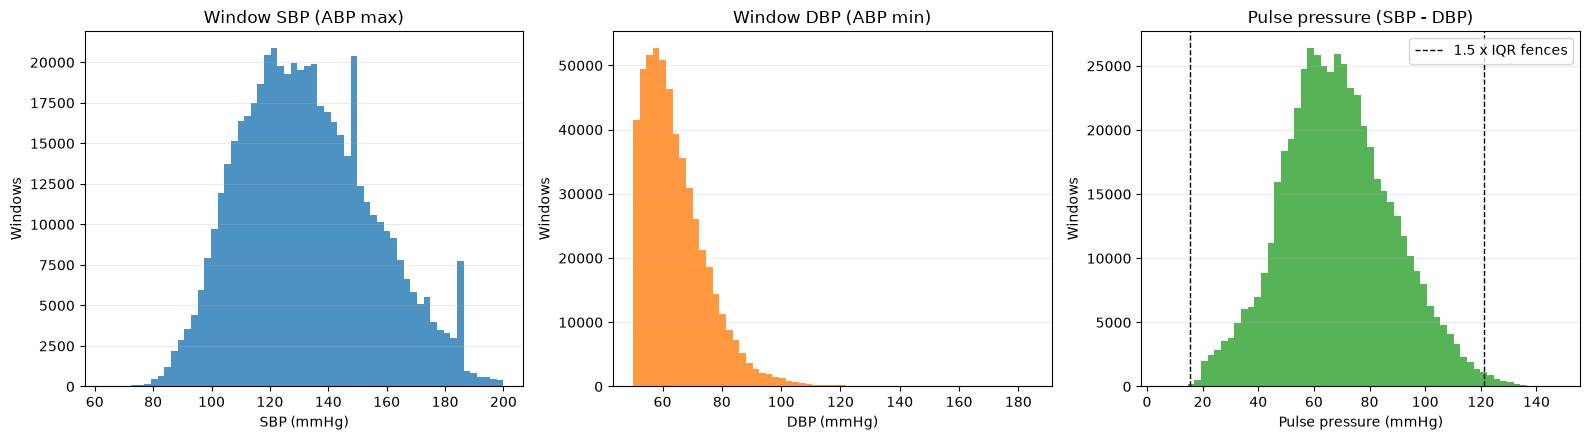

/var/folders/zk/hwf8_sk535n8h_l0lnc5w4b40000gn/T/ipykernel_33133/3023952025.py:75: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.tight_layout()
/Users/katherinewu/Desktop/Microsoft-1D-educational-blood-pressure-estimation/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


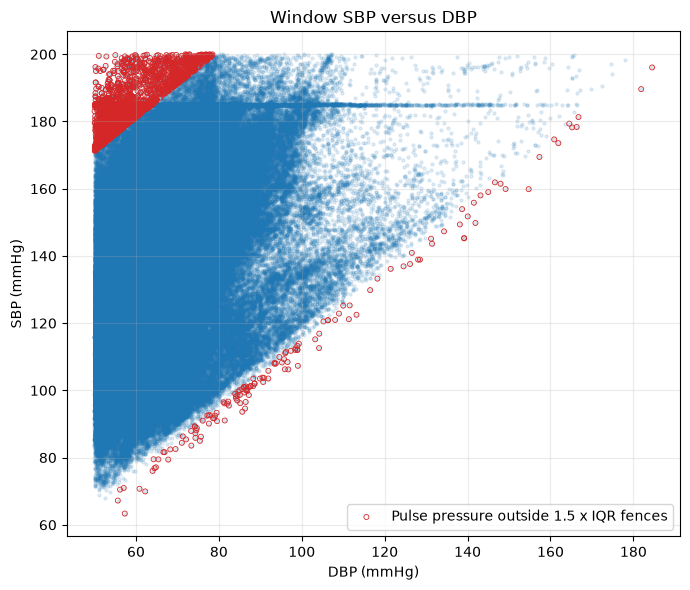

Example pulse-pressure statistical outliers (review waveforms; do not auto-drop):
  PP=133.5, SBP=193.2, DBP=59.7 mmHg; Part_1.mat record 86, window 12
  PP=130.2, SBP=188.3, DBP=58.1 mmHg; Part_1.mat record 87, window 16
  PP=126.6, SBP=190.6, DBP=63.9 mmHg; Part_1.mat record 88, window 84
  PP=132.8, SBP=185.0, DBP=52.2 mmHg; Part_1.mat record 95, window 29
  PP=121.3, SBP=185.0, DBP=63.7 mmHg; Part_1.mat record 95, window 108
  PP=133.0, SBP=183.0, DBP=50.0 mmHg; Part_1.mat record 99, window 3
  PP=130.5, SBP=183.0, DBP=52.5 mmHg; Part_1.mat record 99, window 4
  PP=11.4, SBP=98.6, DBP=87.2 mmHg; Part_1.mat record 105, window 5
  PP=13.7, SBP=100.4, DBP=86.7 mmHg; Part_1.mat record 105, window 21
  PP=12.9, SBP=99.8, DBP=86.8 mmHg; Part_1.mat record 105, window 38


In [ ]:
pulse_pressure = global_sbp - global_dbp

pp_q1, pp_median, pp_q3 = np.quantile(pulse_pressure, [0.25, 0.5, 0.75])
pp_iqr = pp_q3 - pp_q1
pp_lower_fence = pp_q1 - 1.5 * pp_iqr
pp_upper_fence = pp_q3 + 1.5 * pp_iqr
pp_statistical_outliers = (pulse_pressure < pp_lower_fence) | (pulse_pressure > pp_upper_fence)

print(f"Windows summarized: {len(global_sbp):,}")
for label_name, values in (
    ("SBP", global_sbp),
    ("DBP", global_dbp),
    ("Pulse pressure (SBP - DBP)", pulse_pressure),
):
    q05, q25, median, q75, q95 = np.quantile(values, [0.05, 0.25, 0.5, 0.75, 0.95])
    print(
        f"{label_name}: min={values.min():.1f}, 5th={q05:.1f}, "
        f"Q1={q25:.1f}, median={median:.1f}, Q3={q75:.1f}, "
        f"95th={q95:.1f}, max={values.max():.1f} mmHg"
    )
print(f"Pulse pressure <= 0: {np.count_nonzero(pulse_pressure <= 0):,}")
print(
    f"Pulse pressure outside Tukey 1.5xIQR fences "
    f"({pp_lower_fence:.1f}, {pp_upper_fence:.1f} mmHg): "
    f"{np.count_nonzero(pp_statistical_outliers):,} "
    f"({100 * pp_statistical_outliers.mean():.2f}%)"
)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].hist(global_sbp, bins=60, color="tab:blue", alpha=0.8)
axes[0].set_title("Window SBP (ABP max)")
axes[0].set_xlabel("SBP (mmHg)")
axes[0].set_ylabel("Windows")
axes[0].grid(axis="y", alpha=0.25)

axes[1].hist(global_dbp, bins=60, color="tab:orange", alpha=0.8)
axes[1].set_title("Window DBP (ABP min)")
axes[1].set_xlabel("DBP (mmHg)")
axes[1].set_ylabel("Windows")
axes[1].grid(axis="y", alpha=0.25)

axes[2].hist(pulse_pressure, bins=60, color="tab:green", alpha=0.8)
axes[2].axvline(pp_lower_fence, color="black", linestyle="--", linewidth=1, label="1.5 x IQR fences")
axes[2].axvline(pp_upper_fence, color="black", linestyle="--", linewidth=1)
axes[2].set_title("Pulse pressure (SBP - DBP)")
axes[2].set_xlabel("Pulse pressure (mmHg)")
axes[2].set_ylabel("Windows")
axes[2].legend()
axes[2].grid(axis="y", alpha=0.25)

fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(global_dbp, global_sbp, s=5, alpha=0.12, color="tab:blue", rasterized=True)
ax.set_title("Window SBP versus DBP")
ax.set_xlabel("DBP (mmHg)")
ax.set_ylabel("SBP (mmHg)")
ax.grid(alpha=0.25)

outlier_ids = np.flatnonzero(pp_statistical_outliers)
if len(outlier_ids):
    ax.scatter(
        global_dbp[outlier_ids],
        global_sbp[outlier_ids],
        s=13,
        facecolors="none",
        edgecolors="tab:red",
        linewidths=0.6,
        label="Pulse pressure outside 1.5 x IQR fences",
    )
    ax.legend()

fig.tight_layout()
plt.show()

if len(outlier_ids):
    print("Example pulse-pressure statistical outliers (review waveforms; do not auto-drop):")
    for global_id in outlier_ids[:10]:
        part_number, record_index, window_index = map(int, window_locations[global_id])
        print(
            f"  PP={pulse_pressure[global_id]:.1f}, "
            f"SBP={global_sbp[global_id]:.1f}, DBP={global_dbp[global_id]:.1f} mmHg; "
            f"Part_{part_number}.mat record {record_index}, window {window_index}"
        )

# Distribution Takeaways

- SBP is broadly spread, with visible concentrations around 120–150 mmHg and smaller upper-tail clusters. The maximum rounds to 200.0 mmHg, but no window label is exactly 200.0; 16 are at least 199.9 mmHg.
- DBP is concentrated around 50–70 mmHg with a long upper tail. Its maximum, 184.5 mmHg, is unusual relative to most labels and merits waveform review.
- Pulse pressure is mostly around 55–80 mmHg. The 1.5×IQR fences flag 3,240 windows (0.61%) as statistical outliers; these are review candidates, not confirmed bad labels.
- The SBP-vs-DBP scatter has a dense central cloud and unusual pairs, including low pulse pressures where SBP and DBP are close together. The red points are flagged by pulse pressure only and are not independently confirmed as bad signals.

## Additional label, quality, and record-coverage checks

These plots look for apparent label-boundary pileups, summarize PPG window quality indicators, and show how many windows each source record contributes across the combined dataset. Exact boundary values and statistical outliers are review candidates, not automatic exclusions.

Possible target-boundary pileups (window labels):
  SBP exactly 200.0 mmHg: 0
  SBP >= 199.9 mmHg: 16
  DBP exactly 50.0 mmHg: 38
  DBP <= 50.1 mmHg: 1,155
  Example locations for DBP exactly 50:
    Part_1.mat record 2055, window 74
    Part_1.mat record 2055, window 76
    Part_1.mat record 2055, window 77
    Part_1.mat record 2055, window 78
    Part_1.mat record 2055, window 79

PPG zero-count categories per 625-sample window:
  0 zeros: 523,421 (98.98%)
  1 zero: 1,419 (0.27%)
  2-31 zeros: 3,935 (0.74%)
  32+ zeros: 53 (0.01%)


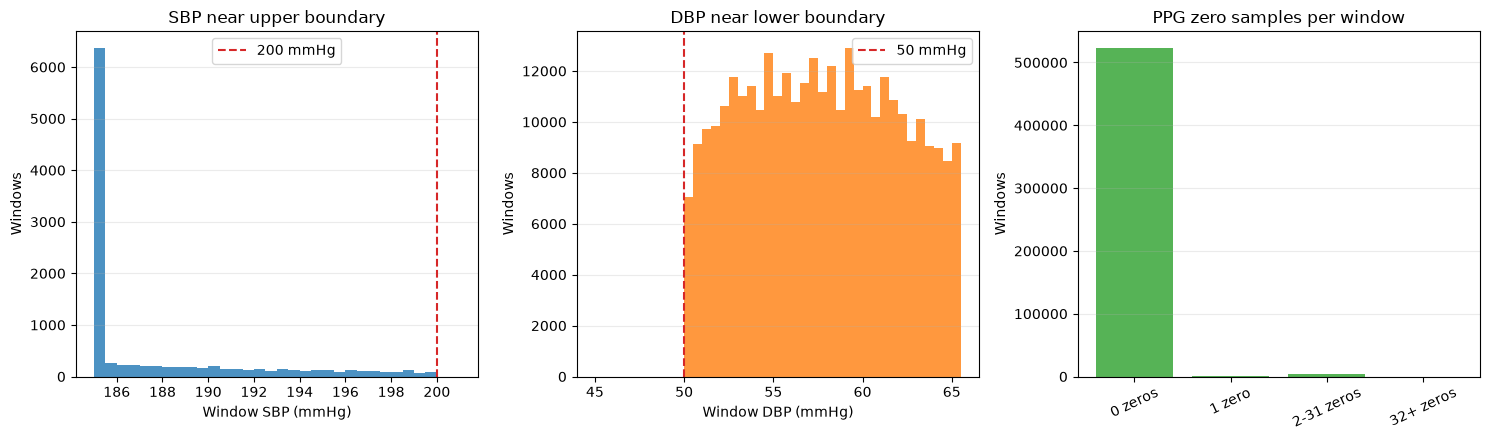

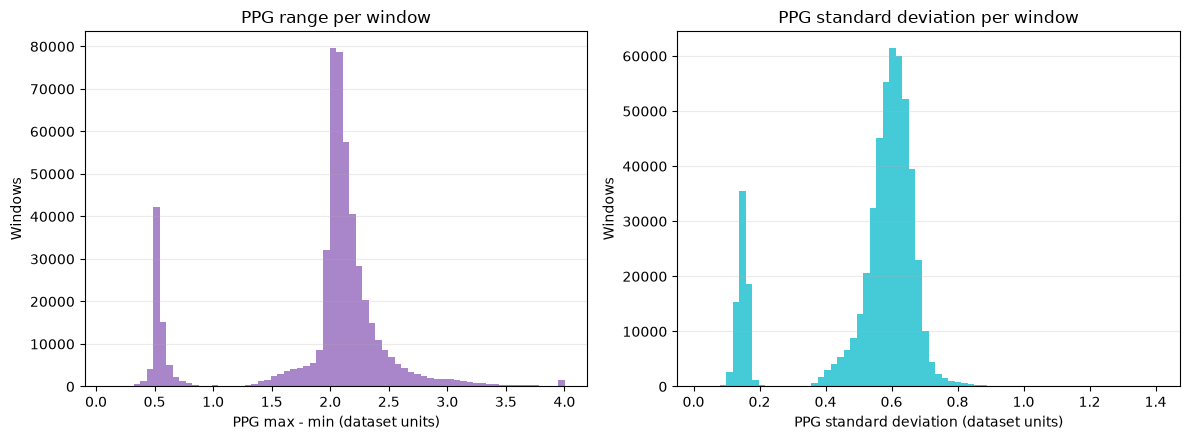

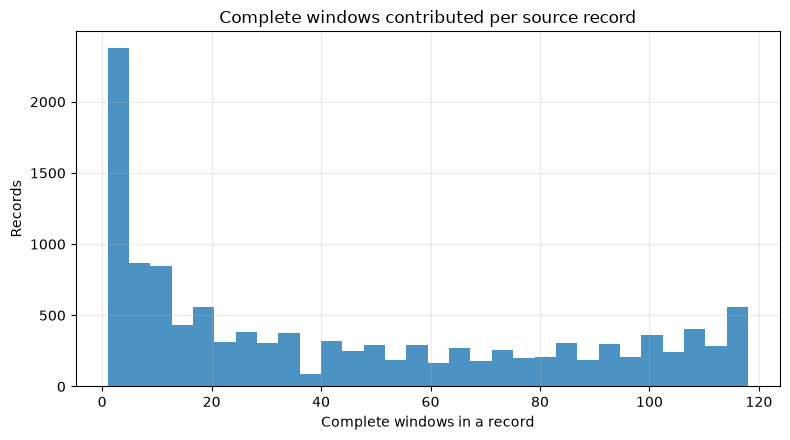

Across all 12,000 source records: 528,828 complete windows, median=32 windows/record, max=118


In [ ]:
pulse_pressure = global_sbp - global_dbp

sbp_at_200 = global_sbp == 200.0
sbp_near_200 = global_sbp >= 199.9
dbp_at_50 = global_dbp == 50.0
dbp_near_50 = global_dbp <= 50.1
print("Possible target-boundary pileups (window labels):")
print(f"  SBP exactly 200.0 mmHg: {np.count_nonzero(sbp_at_200):,}")
print(f"  SBP >= 199.9 mmHg: {np.count_nonzero(sbp_near_200):,}")
print(f"  DBP exactly 50.0 mmHg: {np.count_nonzero(dbp_at_50):,}")
print(f"  DBP <= 50.1 mmHg: {np.count_nonzero(dbp_near_50):,}")

for mask_name, mask in (("SBP exactly 200", sbp_at_200), ("DBP exactly 50", dbp_at_50)):
    ids = np.flatnonzero(mask)[:5]
    if len(ids):
        print(f"  Example locations for {mask_name}:")
        for global_id in ids:
            part_number, record_index, window_index = map(int, window_locations[global_id])
            print(f"    Part_{part_number}.mat record {record_index}, window {window_index}")

zero_categories = np.select(
    [global_zero_counts == 0, global_zero_counts == 1, global_zero_counts >= 32],
    [0, 1, 3],
    default=2,
)
zero_category_labels = ["0 zeros", "1 zero", "2-31 zeros", "32+ zeros"]
zero_category_counts = np.bincount(zero_categories, minlength=4)
zero_category_percent = 100 * zero_category_counts / len(global_zero_counts)
print("\nPPG zero-count categories per 625-sample window:")
for label, count, percent in zip(zero_category_labels, zero_category_counts, zero_category_percent):
    print(f"  {label}: {count:,} ({percent:.2f}%)")

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

axes[0].hist(global_sbp, bins=np.arange(185, 201.5, 0.5), color="tab:blue", alpha=0.8)
axes[0].axvline(200, color="tab:red", linestyle="--", label="200 mmHg")
axes[0].set_title("SBP near upper boundary")
axes[0].set_xlabel("Window SBP (mmHg)")
axes[0].set_ylabel("Windows")
axes[0].legend()
axes[0].grid(axis="y", alpha=0.25)

axes[1].hist(global_dbp, bins=np.arange(45, 66, 0.5), color="tab:orange", alpha=0.8)
axes[1].axvline(50, color="tab:red", linestyle="--", label="50 mmHg")
axes[1].set_title("DBP near lower boundary")
axes[1].set_xlabel("Window DBP (mmHg)")
axes[1].set_ylabel("Windows")
axes[1].legend()
axes[1].grid(axis="y", alpha=0.25)

axes[2].bar(zero_category_labels, zero_category_counts, color="tab:green", alpha=0.8)
axes[2].set_title("PPG zero samples per window")
axes[2].set_ylabel("Windows")
axes[2].tick_params(axis="x", rotation=25)
axes[2].grid(axis="y", alpha=0.25)

fig.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].hist(global_ppg_range, bins=70, color="tab:purple", alpha=0.8)
axes[0].set_title("PPG range per window")
axes[0].set_xlabel("PPG max - min (dataset units)")
axes[0].set_ylabel("Windows")
axes[0].grid(axis="y", alpha=0.25)

axes[1].hist(global_ppg_std, bins=70, color="tab:cyan", alpha=0.8)
axes[1].set_title("PPG standard deviation per window")
axes[1].set_xlabel("PPG standard deviation (dataset units)")
axes[1].set_ylabel("Windows")
axes[1].grid(axis="y", alpha=0.25)

fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(record_window_counts, bins=30, color="tab:blue", alpha=0.8)
ax.set_title("Complete windows contributed per source record")
ax.set_xlabel("Complete windows in a record")
ax.set_ylabel("Records")
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()

print(
    f"Across all {len(record_window_counts):,} source records: "
    f"{record_window_counts.sum():,} complete windows, "
    f"median={np.median(record_window_counts):.0f} windows/record, "
    f"max={record_window_counts.max():,}"
)

### Takeaways: boundary, PPG quality, and record coverage

- **Boundary labels:** No window SBP is exactly 200.0 mmHg, although 16 are at least 199.9. There are 38 windows with DBP exactly 50.0 and 1,155 at or below 50.1 mmHg. The low-DBP concentration merits review for a possible floor effect, but the values alone do not establish clipping or bad labels.
- **PPG quality summaries:** 98.98% of windows have no exact zero, while 0.27% have one, 0.74% have 2–31, and 0.01% have at least 32. Range and standard-deviation histograms show clusters rather than one smooth distribution. Because PPG units are not standardized here, these clusters are signals to investigate, not validated quality thresholds.
- **Windows per record:** Record contributions are uneven across the combined dataset. This makes record-aware splitting important: keep all windows from a source record together, and keep exact duplicate records in the same split. The four file parts are storage divisions, not the recommended evaluation groups.